## Figure Eight periodic orbits - Fourier input tranform with phase shift
---
Although the figure-eight orbit is generally more stable than the Euler and Lagrange families of periodic solutions, and despite its choreographic nature—where all three bodies follow the same trajectory with a constant phase shift of $2\pi/3$—we initially expected the problem to be relatively straightforward for a PINN. In this orbit, the bodies remain well separated throughout the motion, avoiding close encounters and the associated large accelerations that often complicate the learning process.

Contrary to these expectations, the PINN exhibited difficulties in accurately learning three identical trajectories distinguished only by phase shifts. To address this issue, we employed an input transformation that explicitly incorporates phase information and higher-frequency components, thereby facilitating the representation of the choreographic structure of the solution and improving the network's ability to capture the periodic dynamics.
  
* Initial conditions enforced via hard constraints.

* Input transformation used to encode the $120^\circ$ phase shift of the choreographic orbit.

* Similarity transformation applied to normalize the period to $T=1$ without altering the governing ODEs.




In [11]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [14]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

#Training

A $5 \times 64$ neural network architecture was employed without the use of second-order optimization methods such as L-BFGS. Examination of the extrapolation results shows that, although the network provides a reasonable approximation within the training domain, it fails to extrapolate accurately even over an interval of $T/10$.

This behavior does not appear to be caused by overfitting, as the training and test losses remain close throughout training. Instead, it suggests that the network has not yet achieved a sufficiently accurate representation of the solution, possibly due to insufficient training or an unsuitable network architecture.

Possible improvements include:

* Investigating alternative network architectures (e.g., $3 \times 64$, $4 \times 64$, and $5 \times 64$).
* Employing second-order optimization methods such as L-BFGS.
* Increasing the number of training iterations.
* Increasing the number of collocation points.
* Applying a Residual-Based Adaptive Refinement (RAR) strategy to dynamically introduce additional collocation points in regions of high residual error.


In [15]:
dde.config.set_default_float("float64")

seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# Constants
scale=6.3259**(1/3) #scale factor  -- time/scale**3 -- space/scale**2 -- velocities*scale
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 6.3259/scale**3

num_domain = 64 #64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*5 + [6]  # 6 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
optimizer="adam"
#optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-4)

loss_weights = [1]*6    #equal weights
iterations = 300000
learning_rate = 1e-4
eps = 1e-9
print("============================================")
print("activation: ",activation)
print("loss-weights: ",loss_weights)
print("============================================")

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------

# positions
x1_0, y1_0 = -0.97000436/scale**2, 0.24308753/scale**2
x2_0, y2_0 =  0.97000436/scale**2, -0.24308753/scale**2
x3_0, y3_0 =  0.0/scale**2 ,0.0/scale**2

# velocities
vx1_0, vy1_0 = 0.4662036850*scale ,0.4323657300*scale
vx2_0, vy2_0 = 0.4662036850*scale, 0.4323657300*scale
vx3_0, vy3_0 = -0.93240737*scale, -0.86473146*scale

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    r12_3 = (r12)**3
    r13_3 = (r13)**3
    r23_3 = (r23)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test,
    #train_distribution="Hammersley",
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y
# --------------------------------------------------
# INPUT TRANSFORM TO ENFROSCE THE PAHSE DIFFERENCE IN ORBITS
# --------------------------------------------------
omega = 2*np.pi/endTime
phase=2*np.pi/3
def input_transform(x):
    t = x[:, 0:1]

    features = [
        t,
        tf.sin( omega*t),
        tf.cos( omega*t),
        tf.sin( omega*t+phase),
        tf.cos( omega*t+phase),
        tf.sin( 2*omega*t+phase),
        tf.cos( 2*omega*t+phase),


    ]

    return tf.concat(features, axis=1)

#APPLY TRANSFORMS
net.apply_feature_transform(input_transform)
net.apply_output_transform(output_transform)

model = dde.Model(data, net)


#adam
model.compile(optimizer, lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)


model.compile("L-BFGS")  # no learning rate needed
losshistory, train_state = model.train()

# ============================================================
#   SAVE AND LOAD MODEL
# ============================================================
## Load the saved weights
# first - Build the network with dummy predict
#_ = model.predict(np.array([[0.0]]))
#model.restore("Figure-8_Fourier_with_phase-xxxxx.weights.h5")
model.save("Figure-8_Fourier_with_phase")



Set the default float type to float64
activation:  tanh
loss-weights:  [1, 1, 1, 1, 1, 1]
Compiling model...
'compile' took 0.004018 s

Training model...

0         [3.40e+02, 1.23e+02, 1.43e+02, 4.45e+02, 6.29e+02, 9.85e+01]    [2.50e+02, 1.04e+02, 1.02e+02, 3.38e+02, 6.57e+02, 8.32e+01]    []  
1000      [2.76e+01, 1.37e+01, 2.36e+01, 1.90e+00, 1.67e+00, 1.12e+01]    [1.50e+01, 1.52e+01, 1.11e+01, 1.03e+00, 1.91e+00, 1.33e+01]    []  
2000      [1.49e+01, 5.98e+00, 1.13e+01, 1.94e+00, 1.94e+00, 6.97e+00]    [8.43e+00, 6.94e+00, 4.48e+00, 1.59e+00, 2.25e+00, 8.15e+00]    []  
3000      [2.24e+00, 1.25e+00, 2.09e+00, 8.22e-01, 1.18e+00, 2.36e+00]    [1.90e+00, 1.50e+00, 1.38e+00, 8.91e-01, 1.23e+00, 2.80e+00]    []  
4000      [6.39e-01, 5.64e-01, 8.02e-01, 4.51e-01, 6.04e-01, 9.53e-01]    [6.54e-01, 6.75e-01, 6.79e-01, 4.73e-01, 5.49e-01, 1.12e+00]    []  
5000      [2.35e-01, 2.46e-01, 3.34e-01, 2.37e-01, 3.48e-01, 4.21e-01]    [2.65e-01, 2.92e-01, 3.07e-01, 2.35e-01, 3.01e-01, 4.87e

'Figure-8_Fourier_with_phase-315000.weights.h5'

#Plots-Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


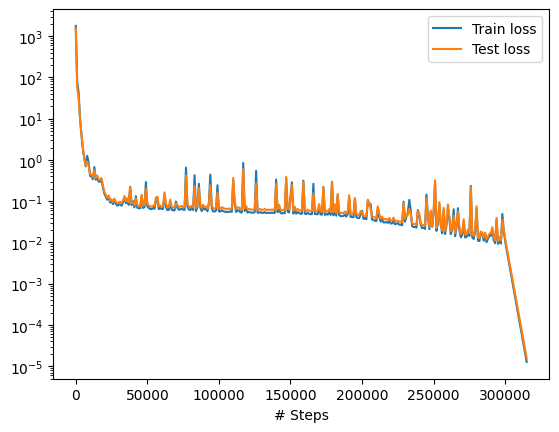

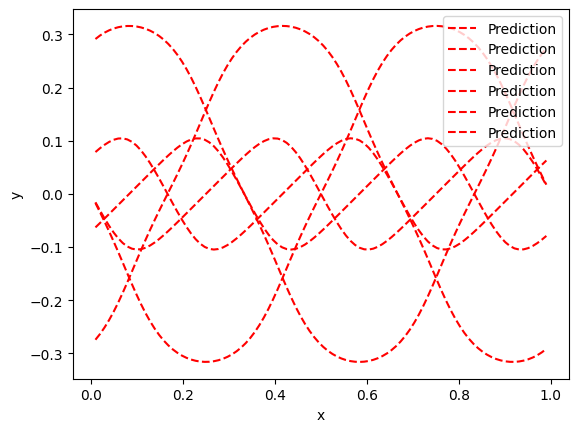

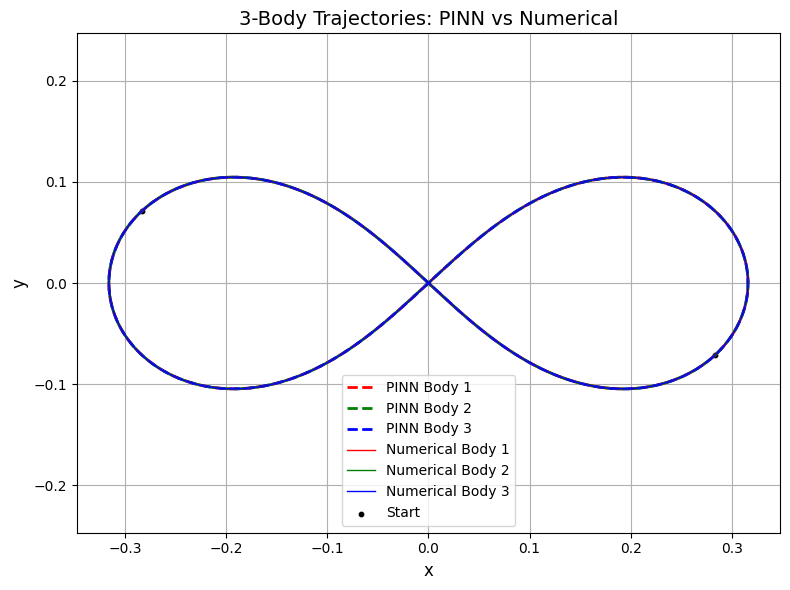


--- L2 Relative Errors ---
Body 1 x error: 4.32e-04
Body 1 y error: 8.97e-04
Body 2 x error: 6.37e-04
Body 2 y error: 1.19e-03
Body 3 x error: 5.86e-04
Body 3 y error: 1.44e-03
(303, 6)


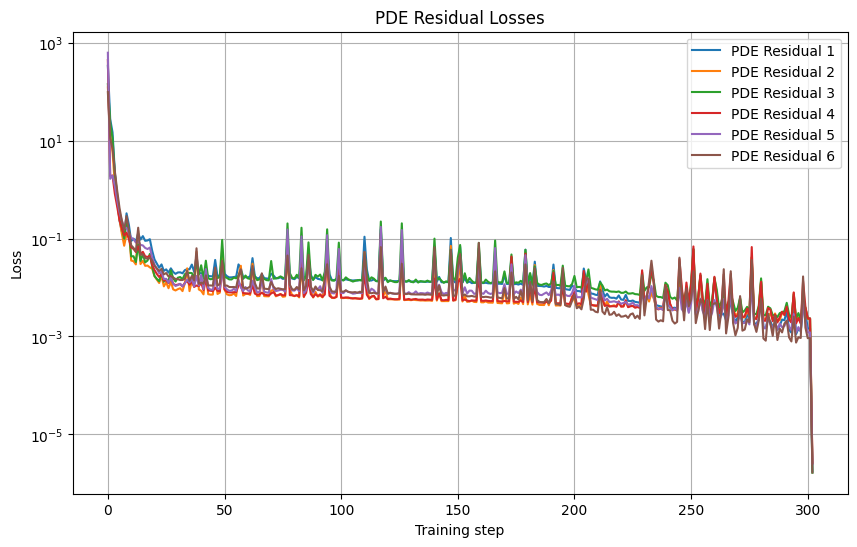

In [16]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()



#STATISTICS

In [17]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

LPDE = final_train_loss     # hard constraints
LDATA = 0.0

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 1.27e-05
Final Test Loss     : 1.59e-05
PDE Residual Loss   : 1.27e-05
Data Loss           : 0.00e+00

Position RMSE
-----------------------------
Body 1 : 1.17e-04
Body 2 : 1.68e-04
Body 3 : 1.68e-04
Global : 1.53e-04

Maximum Position Error
-----------------------------
Body 1 : 2.37e-04
Body 2 : 3.34e-04
Body 3 : 3.93e-04
Global Max Position error : 3.93e-04

Energy Conservation
-----------------------------
PINN ΔE/E0 : 1.64e-04
-----------------------------
Numerical ΔE/E0 : 2.91e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 7.22e-05
-----------------------------
Numerical Max Momentum Drift : 2.67e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 4.75e+10


SUMMARY
Final Training Loss               : 1.27e-05
Final Test Loss                   : 1.59e-05
PDE Residual Loss                 : 1.27e-05
Data Loss                         : 0.00e+00
Global Max Position error         : 3.93e-04
Positi

#PHASE PLOTS FOR ONE PERIOD

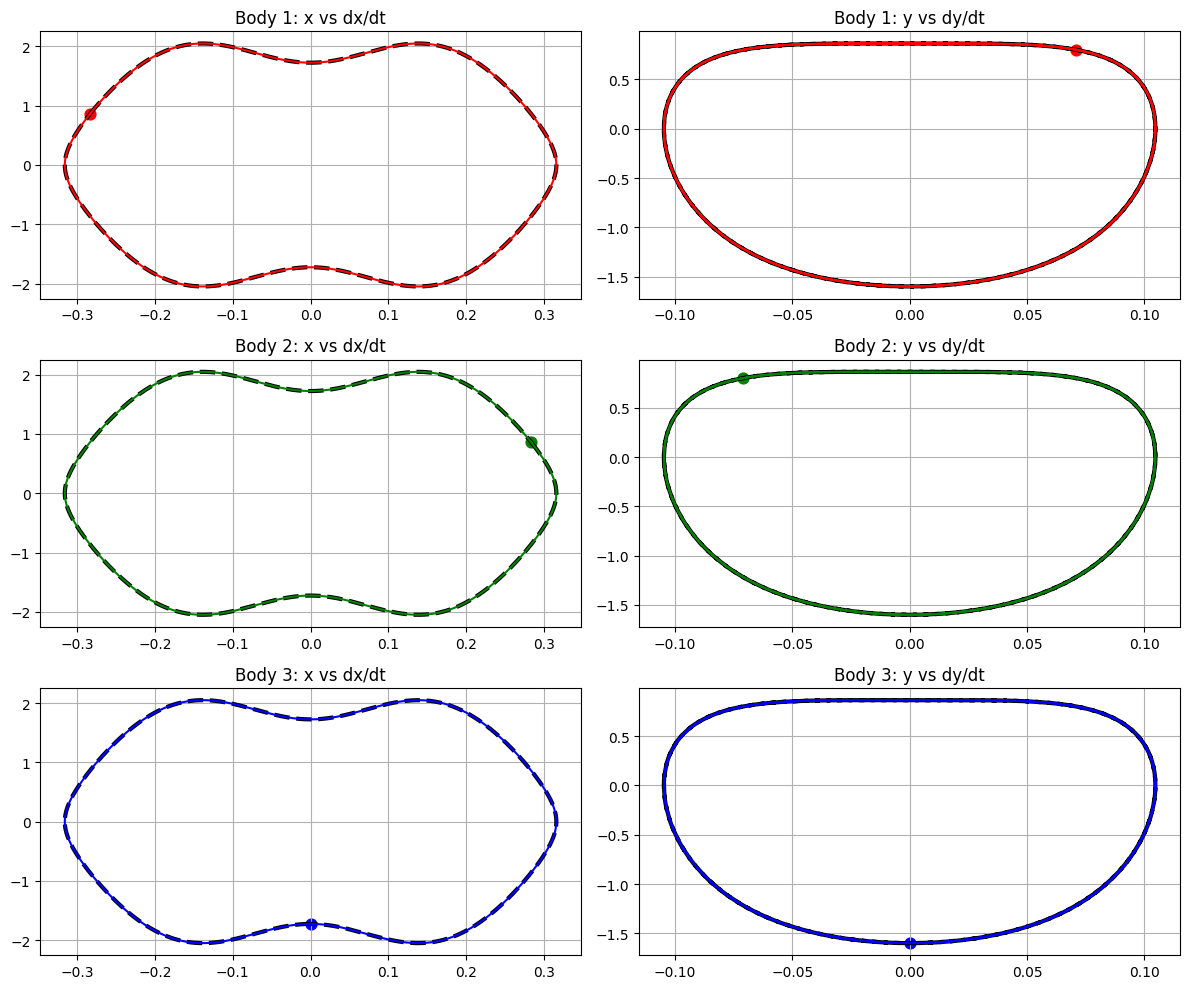

In [18]:
# ============================================================
# PHASE DIAGRAMS (PINN vs Numerical) using autodiff velocities
# ============================================================

#RESTORE endTime
endTime=1
t_test = np.linspace(0, endTime, 5000)[:, None]


# ============================================================
# PHASE DIAGRAMS (PINN vs Numerical) using autodiff velocities
# ============================================================

t_tf = tf.convert_to_tensor(t_test)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred = model.net(t_tf)

# Jacobian gives derivatives of each output wrt time
dy_dt = tape.batch_jacobian(y_pred, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:,:,0]

y_pred = y_pred.numpy()
dy_dt = dy_dt.numpy()

# PINN positions
x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1_p, vy1_p = dy_dt[:,0], dy_dt[:,1]
vx2_p, vy2_p = dy_dt[:,2], dy_dt[:,3]
vx3_p, vy3_p = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]



# --- numerical velocities ---
vx1_n, vy1_n = sol.y[2], sol.y[3]
vx2_n, vy2_n = sol.y[6], sol.y[7]
vx3_n, vy3_n = sol.y[10], sol.y[11]

# ============================================================
# PHASE PLOTS
# ============================================================

fig, axes = plt.subplots(3,2, figsize=(12,10))

axes[0,0].plot(x1, vx1_p, 'k--',lw=3, label="PINN")
axes[0,0].plot(x1_n, vx1_n, 'r', label="Numerical")
axes[0,0].scatter(x1_n[0], vx1_n[0], color='r', s=60, label="Start")
axes[0,0].set_title("Body 1: x vs dx/dt")
axes[0,0].grid()

axes[0,1].plot(y1, vy1_p, 'k--',lw=3)
axes[0,1].plot(y1_n, vy1_n, 'r')
axes[0,1].scatter(y1_n[0], vy1_n[0], color='r', s=60, label="Start")
axes[0,1].set_title("Body 1: y vs dy/dt")
axes[0,1].grid()

axes[1,0].plot(x2, vx2_p, 'k--',lw=3)
axes[1,0].plot(x2_n, vx2_n, 'g')
axes[1,0].scatter(x2_n[0], vx2_n[0], color='g', s=60, label="Start")
axes[1,0].set_title("Body 2: x vs dx/dt")
axes[1,0].grid()

axes[1,1].plot(y2, vy2_p, 'k--',lw=3)
axes[1,1].plot(y2_n, vy2_n, 'g')
axes[1,1].scatter(y2_n[0], vy2_n[0], color='g', s=60, label="Start")
axes[1,1].set_title("Body 2: y vs dy/dt")
axes[1,1].grid()

axes[2,0].plot(x3, vx3_p, 'k--',lw=3)
axes[2,0].plot(x3_n, vx3_n, 'b')
axes[2,0].scatter(x3_n[0], vx3_n[0], color='b', s=60, label="Start")
axes[2,0].set_title("Body 3: x vs dx/dt")
axes[2,0].grid()

axes[2,1].plot(y3, vy3_p, 'k--',lw=3)
axes[2,1].plot(y3_n, vy3_n, 'b')
axes[2,1].scatter(y3_n[0], vy3_n[0], color='b', s=60, label="Start")
axes[2,1].set_title("Body 3: y vs dy/dt")
axes[2,1].grid()

plt.tight_layout()
plt.show()

#PHASE PLOTS FOR HALF A PERIOD

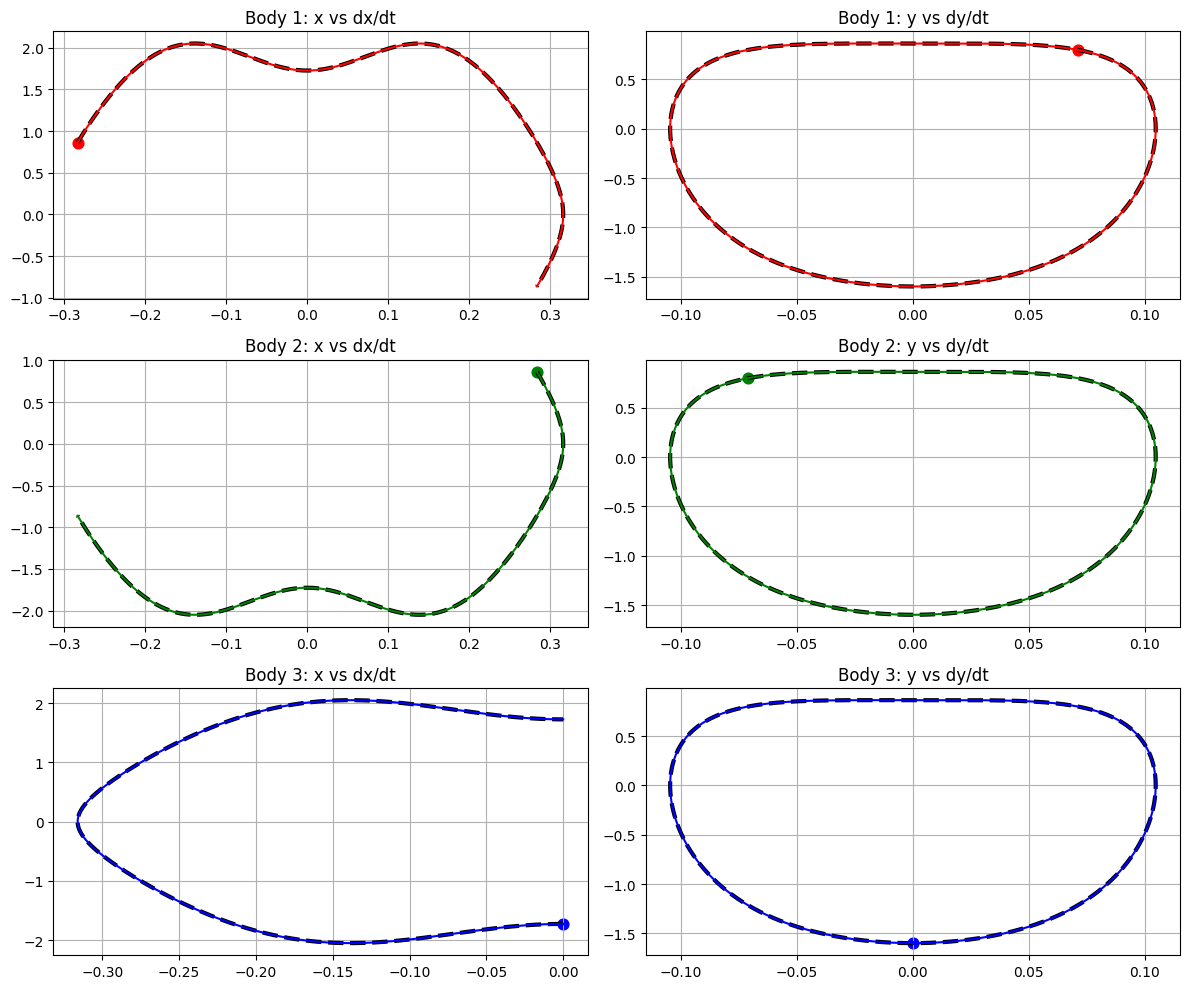

In [19]:
# ============================================================
# PHASE DIAGRAMS (PINN vs Numerical) using autodiff velocities
# ============================================================

#RESTORE endTime
endTime=1/2
t_test = np.linspace(0, endTime, 5000)[:, None]

# ============================================================
# PHASE DIAGRAMS (PINN vs Numerical) using autodiff velocities
# ============================================================

t_tf = tf.convert_to_tensor(t_test)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred = model.net(t_tf)

# Jacobian gives derivatives of each output wrt time
dy_dt = tape.batch_jacobian(y_pred, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:,:,0]

y_pred = y_pred.numpy()
dy_dt = dy_dt.numpy()

# PINN positions
x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1_p, vy1_p = dy_dt[:,0], dy_dt[:,1]
vx2_p, vy2_p = dy_dt[:,2], dy_dt[:,3]
vx3_p, vy3_p = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]



# --- numerical velocities ---
vx1_n, vy1_n = sol.y[2], sol.y[3]
vx2_n, vy2_n = sol.y[6], sol.y[7]
vx3_n, vy3_n = sol.y[10], sol.y[11]

# ============================================================
# PHASE PLOTS
# ============================================================

fig, axes = plt.subplots(3,2, figsize=(12,10))

axes[0,0].plot(x1, vx1_p, 'k--',lw=3, label="PINN")
axes[0,0].plot(x1_n, vx1_n, 'r', label="Numerical")
axes[0,0].scatter(x1_n[0], vx1_n[0], color='r', s=60, label="Start")
axes[0,0].set_title("Body 1: x vs dx/dt")
axes[0,0].grid()

axes[0,1].plot(y1, vy1_p, 'k--',lw=3)
axes[0,1].plot(y1_n, vy1_n, 'r')
axes[0,1].scatter(y1_n[0], vy1_n[0], color='r', s=60, label="Start")
axes[0,1].set_title("Body 1: y vs dy/dt")
axes[0,1].grid()

axes[1,0].plot(x2, vx2_p, 'k--',lw=3)
axes[1,0].plot(x2_n, vx2_n, 'g')
axes[1,0].scatter(x2_n[0], vx2_n[0], color='g', s=60, label="Start")
axes[1,0].set_title("Body 2: x vs dx/dt")
axes[1,0].grid()

axes[1,1].plot(y2, vy2_p, 'k--',lw=3)
axes[1,1].plot(y2_n, vy2_n, 'g')
axes[1,1].scatter(y2_n[0], vy2_n[0], color='g', s=60, label="Start")
axes[1,1].set_title("Body 2: y vs dy/dt")
axes[1,1].grid()

axes[2,0].plot(x3, vx3_p, 'k--',lw=3)
axes[2,0].plot(x3_n, vx3_n, 'b')
axes[2,0].scatter(x3_n[0], vx3_n[0], color='b', s=60, label="Start")
axes[2,0].set_title("Body 3: x vs dx/dt")
axes[2,0].grid()

axes[2,1].plot(y3, vy3_p, 'k--',lw=3)
axes[2,1].plot(y3_n, vy3_n, 'b')
axes[2,1].scatter(y3_n[0], vy3_n[0], color='b', s=60, label="Start")
axes[2,1].set_title("Body 3: y vs dy/dt")
axes[2,1].grid()

plt.tight_layout()
plt.show()

#Extrapolate for 1/10 of period

======================= Extrapolating for 1/10 Period ===============================


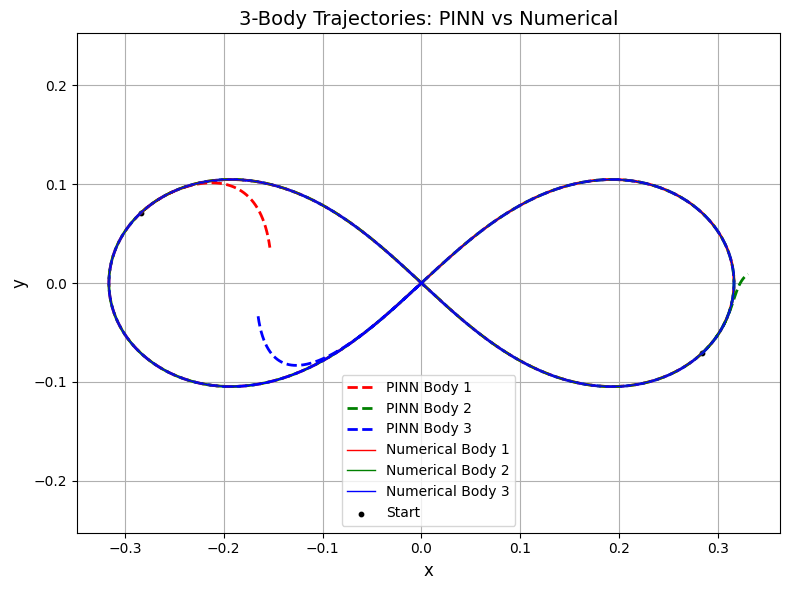


--- L2 Relative Errors ---
Body 1 x error: 1.16e-02
Body 1 y error: 6.53e-02
Body 2 x error: 5.82e-03
Body 2 y error: 5.73e-03
Body 3 x error: 1.01e-02
Body 3 y error: 8.95e-02


In [20]:
#============================ EXTRAPOLATE =================================================
print("===================================================================================")
print("======================= Extrapolating for 1/10 Period ===============================")
print("===================================================================================")

#RESTORE endTime
endTime=1
endTime=endTime+endTime/10

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")